# Decision Making using Court Line Detection and Ball Detection


In [102]:
# Import Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import easygui

Selected: C:\Users\negri\Documents\Year4\.Semester 1\Image Processing\Volleyball-Line-Detection\sample_images\Sample_Input_3.jpg


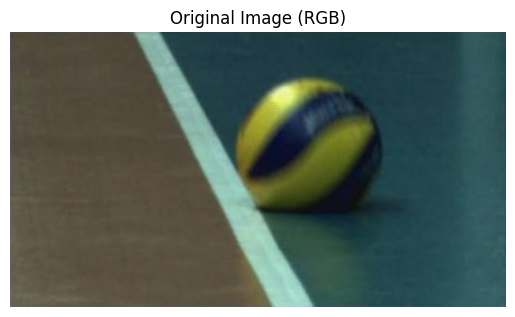

In [103]:
# Initial block for image loading and normalising, we should use this as the base 
# for both the line detection and ball detection so we have a consistent image variables.
# Let the user pick an image
input_path = easygui.fileopenbox("Select volleyball court image:")
print("Selected:", input_path)

image_bgr = cv2.imread(input_path)
if image_bgr is None:
    raise ValueError("Could not read image, check the path.")

# resize to a consistent width
target_width = 800
h, w = image_bgr.shape[:2]
scale = target_width / w
image_bgr = cv2.resize(image_bgr, (target_width, int(h * scale)))

# Convert to RGB for matplotlib
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("Original Image (RGB)")
plt.axis("off")
plt.show()

### Pre-Processing, Hough Lines, Canny Edges, Court Line Polygon ROI
Extracting the Court Lines

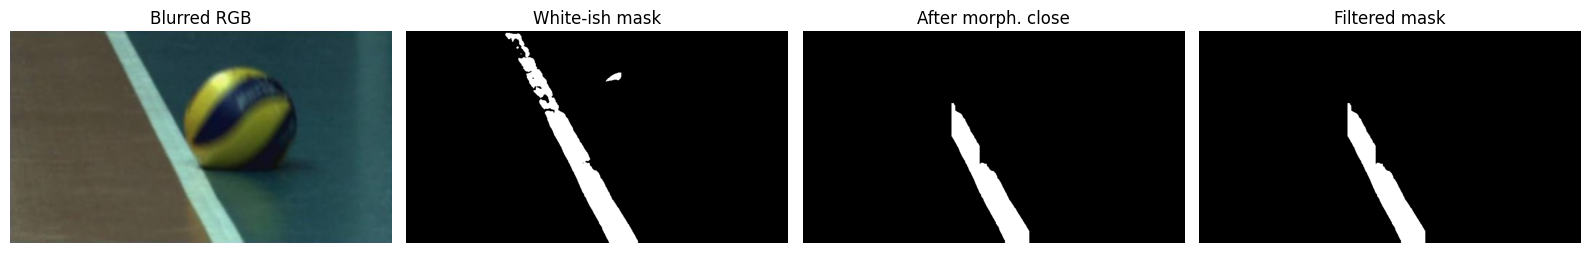

In [104]:
# PreProcessing, Color Mask and Connected Components for Line Detection
def PreProcess_ExtractLines(image_bgr, min_area=150, debug=False):

    # Light denoising
    blurred_bgr = cv2.GaussianBlur(image_bgr, (5, 5), 0)
    blurred_rgb = cv2.cvtColor(blurred_bgr, cv2.COLOR_BGR2RGB)

    # Convert to HSV (for brightness / saturation masking)
    hsv = cv2.cvtColor(blurred_bgr, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)

    # Threshold on brightness (V) and low saturation (S) to get whitish regions
    _, v_mask = cv2.threshold(V, 180, 255, cv2.THRESH_BINARY) # very bright
    _, s_mask = cv2.threshold(S, 100, 255, cv2.THRESH_BINARY_INV) # low saturation 

    white_mask = cv2.bitwise_and(v_mask, s_mask)

    # Morphology to clean up and join courtline fragments slightly more
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 50))
    opened = cv2.morphologyEx(white_mask, cv2.MORPH_OPEN, kernel_open, iterations=1)

    vert_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 9))
    line_mask = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, vert_kernel, iterations=1)

    # Connected components, keep only sufficiently large bright regions
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(line_mask)

    # min_area = 150 # remove tiny blobs
    filtered = np.zeros_like(line_mask)

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            filtered[labels == i] = 255

    # Return everything you actually need
    return blurred_rgb, white_mask, line_mask, filtered

blurred_rgb, white_mask, line_mask, filtered = PreProcess_ExtractLines(image_bgr)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(blurred_rgb); axes[0].set_title("Blurred RGB"); axes[0].axis("off")
axes[1].imshow(white_mask, cmap="gray"); axes[1].set_title("White-ish mask"); axes[1].axis("off")
axes[2].imshow(line_mask, cmap="gray"); axes[2].set_title("After morph. close"); axes[2].axis("off")
axes[3].imshow(filtered, cmap="gray"); axes[3].set_title("Filtered mask"); axes[3].axis("off")
plt.tight_layout(); plt.show()


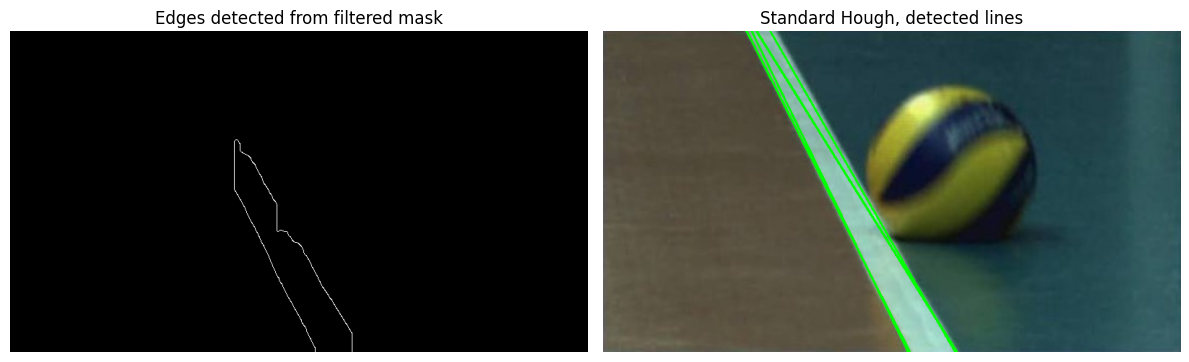

In [105]:
# Canny edges, Hough transforms (segments and infinite lines)
def detect_HoughLines(filtered, image_rgb):

    # Edges from filtered mask
    edges = cv2.Canny(filtered, 50, 150, apertureSize=3)

    # Standard Hough: This is what we use for the stripe ROI
    vis = image_rgb.copy()

    lines = cv2.HoughLines(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=80 
    )

    if lines is not None:
        for i in range(len(lines)):
            rho, theta = lines[i][0]
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho

            # two far points for drawing
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))

            cv2.line(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)

        return edges, vis, lines
    
edges, vis, lines = detect_HoughLines(filtered, image_rgb)

# Show edges
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left: edges
axes[0].imshow(edges, cmap="gray")
axes[0].set_title("Edges detected from filtered mask")
axes[0].axis("off")

# Right: Hough lines
axes[1].imshow(vis)
axes[1].set_title("Standard Hough, detected lines")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Dominant theta (deg): 151.49998
Hough lines near dominant orientation for ROI: 4


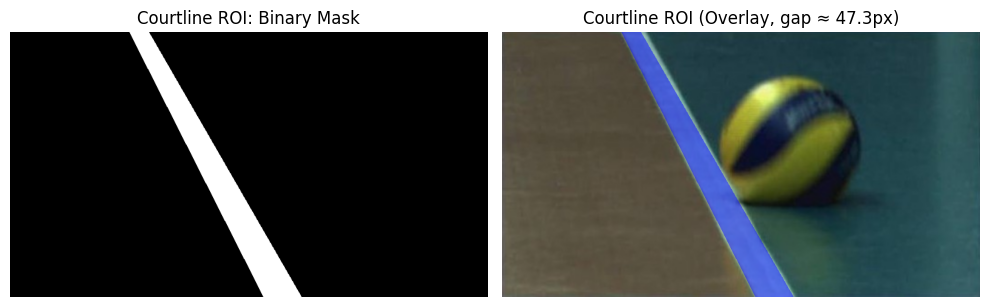

In [106]:
# Courtline polygon ROI (works for vertical & angled stripes)
# Outputs a binary mask of courtline and visual overlay that we can use
# for our decision method.
def compute_courtline_ROI(image_rgb, lines):
    h, w = image_rgb.shape[:2]

    def angle_diff(a, b):
        """Smallest difference between two angles in [0, pi]."""
        d = abs(a - b)
        return min(d, np.pi - d)

    def line_x_at_y(rho, theta, y):
        """Return x where line (rho, theta) crosses y, or None if invalid."""
        c = np.cos(theta)
        if abs(c) < 1e-3: # avoid division by zero if nearly horizontal
            return None
        return (rho - y * np.sin(theta)) / c
    
    # Estimate dominant line orientation from Hough lines
    dominant_theta = None
    if lines is not None:
        thetas = [l[0][1] for l in lines] # theta from each (rho, theta)
        if len(thetas) > 0:
            dominant_theta = np.median(thetas)
            print("Dominant theta (deg):", np.degrees(dominant_theta))
        else:
            print("No thetas from Hough lines.")
    else:
        print("No Hough lines found; cannot estimate dominant orientation.")
    
    # Collect candidate border lines near the dominant orientation
    border_lines = [] # list of (x_mid, rho, theta)
    if lines is not None and dominant_theta is not None:
        for i in range(len(lines)):
            rho, theta = lines[i][0]

            # keep only lines whose angle is close to the dominant stripe angle
            if angle_diff(theta, dominant_theta) > np.deg2rad(10):
                continue

            # must intersect top and bottom inside the image
            x_top = line_x_at_y(rho, theta, 0)
            x_bot = line_x_at_y(rho, theta, h - 1)
            if x_top is None or x_bot is None:
                continue
            if not (0 <= x_top < w and 0 <= x_bot < w):
                continue

            # x at vertical centre (y = h/2) for measuring the gap
            x_mid = line_x_at_y(rho, theta, h / 2.0)
            if x_mid is None or not (0 <= x_mid < w):
                continue

            border_lines.append((x_mid, rho, theta))
    print("Hough lines near dominant orientation for ROI:", len(border_lines))

    # Choose the pair with the largest sensible gap at centre (this is the full width of courtline)
    if len(border_lines) >= 2:
        max_rel_width = 0.15 # 15% of image width (upper bound)
        min_rel_width = 0.01 # 1% of width (lower bound)
        max_width_px = max_rel_width * w
        min_width_px = min_rel_width * w

        best_pair = None
        best_gap  = -1.0

        # try all pairs 
        for i in range(len(border_lines)):
            x1, rho1, theta1 = border_lines[i]
            for j in range(i + 1, len(border_lines)):
                x2, rho2, theta2 = border_lines[j]
                gap = abs(x2 - x1)

                if gap < min_width_px or gap > max_width_px:
                    continue

                if gap > best_gap:
                    best_gap  = gap
                    best_pair = (x1, rho1, theta1, x2, rho2, theta2)
        
        # Fallback, if nothing obeys the width constraint, use outermost pair
        if best_pair is None:
            border_lines.sort(key=lambda t: t[0])
            x1, rho1, theta1 = border_lines[0]
            x2, rho2, theta2 = border_lines[-1]
            best_gap = abs(x2 - x1)
            best_pair = (x1, rho1, theta1, x2, rho2, theta2)
            print("Fallback, using extreme pair without width constraint.")

        if best_pair is not None:
            xmid1, rho1, theta1, xmid2, rho2, theta2 = best_pair

            # Build polygon between these two lines using top & bottom intersections
            x1_top = line_x_at_y(rho1, theta1, 0)
            x1_bottom = line_x_at_y(rho1, theta1, h - 1)
            x2_top = line_x_at_y(rho2, theta2, 0)
            x2_bottom = line_x_at_y(rho2, theta2, h - 1)

            pts = np.array([
                [int(round(x1_top)), 0],
                [int(round(x2_top)), 0],
                [int(round(x2_bottom)), h - 1],
                [int(round(x1_bottom)), h - 1]
            ], dtype=np.int32)

            # final courtline mask (polygon ROI)
            line_roi_mask = np.zeros((h, w), dtype=np.uint8)
            cv2.fillPoly(line_roi_mask, [pts], 255)

            # Overlay
            vis_roi = image_rgb.copy()
            overlay = vis_roi.copy()
            cv2.fillPoly(overlay, [pts], (0, 0, 255))
            vis_roi = cv2.addWeighted(overlay, 0.5, vis_roi, 0.5, 0)

            return line_roi_mask, vis_roi, best_gap
        
        else:
            print("No suitable pair of lines found for polygon ROI.")
            return None, None, None
    else:
        print("Not enough Hough lines / no dominant orientation to build polygon ROI.")
        return None, None, None

line_roi_mask, vis_roi, best_gap = compute_courtline_ROI(image_rgb, lines)

if line_roi_mask is not None:
    fig, axes = plt.subplots(1, 2, figsize=(10, 6))

    axes[0].imshow(line_roi_mask, cmap="gray")
    axes[0].set_title("Courtline ROI: Binary Mask")
    axes[0].axis("off")

    axes[1].imshow(vis_roi)
    axes[1].set_title(f"Courtline ROI (Overlay, gap ≈ {best_gap:.1f}px)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()



### Ball Detection

Extracting the Ball

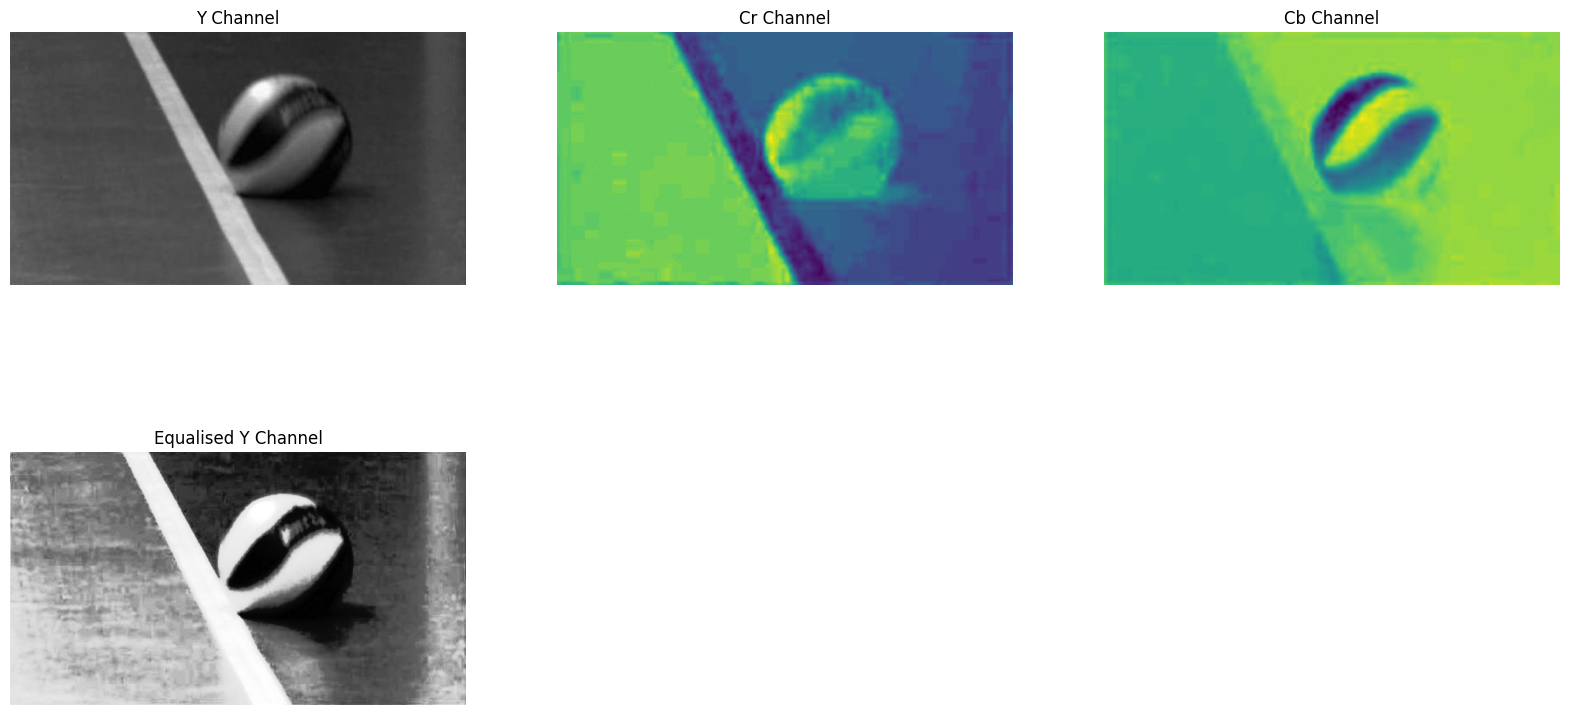

In [107]:
# Function to extract YCrCb channels and equalize the Y channel, displaying each step
def preprocess_channels(image_bgr):
    """Extract Y, Cr, Cb and equalised Y from the input image."""
    YCrCb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2YCrCb)
    Y, Cr, Cb = cv2.split(YCrCb)
    equalised_y = cv2.equalizeHist(Y)
    YCrCb_eq = cv2.merge([equalised_y, Cr, Cb])

    plt.figure(figsize=(20,10))
    plt.subplot(2,3,1)
    plt.title('Y Channel')
    plt.imshow(Y, cmap='gray')
    plt.axis('off')
    
    plt.subplot(2,3,2)
    plt.title('Cr Channel')
    plt.imshow(Cr)
    plt.axis('off')
    
    plt.subplot(2,3,3)
    plt.title('Cb Channel')
    plt.imshow(Cb)
    plt.axis('off')
    
    plt.subplot(2,3,4)
    plt.title('Equalised Y Channel')
    plt.imshow(equalised_y, cmap='gray')
    plt.axis('off')

    # plt.tight_layout()
    plt.show()
    return Y, Cr, Cb, equalised_y, YCrCb_eq

# Example usage:
Y, Cr, Cb, equalised_y, YCrCb_eq = preprocess_channels(image_bgr)

### Detecting Ball on GrayScale Image (Karl's Original Code)

In [108]:
# def detect_ball(image_bgr):
#     # Convert image to grayscale
#     gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
#     # Apply a slight blur to reduce noise
#     blurred = cv2.medianBlur(gray, 5)

#     # Try Hough Circle detection first
#     circles = cv2.HoughCircles(
#         blurred,
#         cv2.HOUGH_GRADIENT,
#         dp=1.2,
#         minDist=40,
#         param1=80,
#         param2=15,
#         minRadius=10,
#         maxRadius=100
#     )
#     ball = None

#     # If Hough Circles found, use the largest
#     if circles is not None:
#         circles = np.uint16(np.around(circles))
#         main_circle = circles[0][0]
#         center = (main_circle[0], main_circle[1])
#         radius = main_circle[2]
#         ball = {'type': 'circle', 'center': center, 'radius': radius}
#     else:
#         # Fallback to contour-based ellipse fitting
#         _, thresh = cv2.threshold(blurred, 60, 255, cv2.THRESH_BINARY)
#         contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#         max_area = 0
#         best_contour = None
#         for c in contours:
#             area = cv2.contourArea(c)
#             perimeter = cv2.arcLength(c, True)
#             if perimeter == 0 or area < 200:
#                 continue
#             circularity = 4 * np.pi * area / (perimeter * perimeter)
#             # Prioritize actual size for robustness
#             if area > max_area and circularity > 0.72:
#                 max_area = area
#                 best_contour = c
#         if best_contour is not None and len(best_contour) >= 5:
#             ellipse = cv2.fitEllipse(best_contour)
#             ball = {'type': 'ellipse', 'ellipse': ellipse}

#     # Draw results
#     ball_img = image_bgr.copy()
#     if ball is not None:
#         if ball['type'] == 'circle':
#             cv2.circle(ball_img, ball['center'], ball['radius'], (255, 0, 0), 3)
#             cv2.circle(ball_img, ball['center'], 2, (0, 0, 255), 3)
#         elif ball['type'] == 'ellipse':
#             cv2.ellipse(ball_img, ball['ellipse'], (0, 255, 0), 3)
            
#     plt.figure(figsize=(8,8))
#     plt.imshow(cv2.cvtColor(ball_img, cv2.COLOR_BGR2RGB))
#     plt.title("Ball Detection")
#     plt.axis('off')
#     plt.show()

#     return ball

# # Usage:
# ball = detect_ball(image_bgr)


### Detecting Ball from Y Channel in YCrCb (Karl's Original Code)

In [109]:
# def detect_ball_from_y(image_bgr, Y):
#     # Use the already-preprocessed Y channel, and apply a blur to reduce noise
#     blurred = cv2.medianBlur(Y, 5)

#     # Try Hough Circle detection first
#     circles = cv2.HoughCircles(
#         blurred,
#         cv2.HOUGH_GRADIENT,
#         dp=1.2,
#         minDist=40,
#         param1=80,
#         param2=15,
#         minRadius=10,
#         maxRadius=100
#     )
#     ball = None

#     if circles is not None:
#         circles = np.uint16(np.around(circles))
#         main_circle = circles[0][0]
#         center = (main_circle[0], main_circle[1])
#         radius = main_circle[2]
#         ball = {'type': 'circle', 'center': center, 'radius': radius}
#     else:
#         # If no circle, fallback to contour-based ellipse
#         _, thresh = cv2.threshold(blurred, 60, 255, cv2.THRESH_BINARY)
#         contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#         max_area = 0
#         best_contour = None
#         for c in contours:
#             area = cv2.contourArea(c)
#             perimeter = cv2.arcLength(c, True)
#             if perimeter == 0 or area < 200:
#                 continue
#             circularity = 4 * np.pi * area / (perimeter * perimeter)
#             if area > max_area and circularity > 0.72:
#                 max_area = area
#                 best_contour = c
#         if best_contour is not None and len(best_contour) >= 5:
#             ellipse = cv2.fitEllipse(best_contour)
#             ball = {'type': 'ellipse', 'ellipse': ellipse}

#     # Draw results
#     ball_img = image_bgr.copy()
#     if ball is not None:
#         if ball['type'] == 'circle':
#             cv2.circle(ball_img, ball['center'], ball['radius'], (255, 0, 0), 3)
#             cv2.circle(ball_img, ball['center'], 2, (0, 0, 255), 3)
#         elif ball['type'] == 'ellipse':
#             cv2.ellipse(ball_img, ball['ellipse'], (0, 255, 0), 3)
            
#     plt.figure(figsize=(8,8))
#     plt.imshow(cv2.cvtColor(ball_img, cv2.COLOR_BGR2RGB))
#     plt.title("Ball Detection (Y Channel)")
#     plt.axis('off')
#     plt.show()

#     return ball

# # Usage:
# ball = detect_ball_from_y(image_bgr, Y)

### Ball Detection

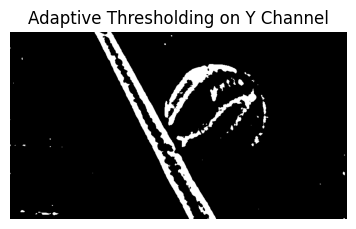

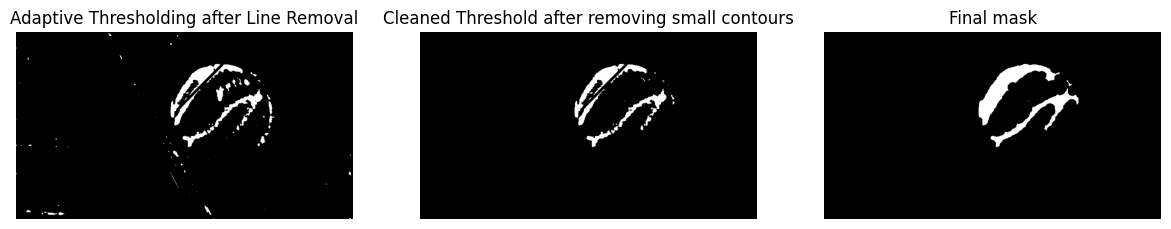

In [110]:
def create_ball_mask(image_bgr):
    image_bgr = cv2.GaussianBlur(image_bgr, (5, 5), 0)
    image_ycrcb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2YCrCb)
    Y, Cr, Cb = cv2.split(image_ycrcb)

    # Adatptive thresholding on Y channel which filters out some lines and the ball
    adaptive_thresh = cv2.adaptiveThreshold(Y, maxValue=255, adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                           thresholdType=cv2.THRESH_BINARY, blockSize=49, C=-5)
    # Displays the adaptive threshold result (can be removed if you want)
    plt.figure(figsize=(20,10))
    plt.subplot(1,4,1)
    plt.title('Adaptive Thresholding on Y Channel')
    plt.imshow(adaptive_thresh, cmap='gray')
    plt.axis('off')

    ## -----This section removes court lines from the thresholded image---- ##
    
    # Detect the inner and outer edge of the court line using hough transform
    lines = cv2.HoughLinesP(adaptive_thresh, rho=1, theta=np.pi/180, threshold=200,
                            minLineLength=50, maxLineGap=10)

    # Remove detected lines from adaptive_thresh
    if lines is not None: 
        for line in lines:
            x1, y1, x2, y2 = line[0] # Extract line endpoints
            cv2.line(adaptive_thresh, pt1=(x1, y1), pt2=(x2, y2), color=(0), thickness=5)
    ## --------------------------------------------------------------- ##

    # Remove the noise by removing small contours
    contours, _ = cv2.findContours(adaptive_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    min_contour_area = 400
    cleaned_thresh = np.zeros_like(adaptive_thresh)
    for contour in contours:
        if cv2.contourArea(contour) >= min_contour_area:
            cv2.drawContours(cleaned_thresh, [contour], -1, color=255, thickness=-1)

    # Close gaps in the detected contours
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    closed_thresh = cv2.morphologyEx(cleaned_thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    # Dialate to further close gaps
    closed_thresh = cv2.dilate(closed_thresh, kernel, iterations=10)

    # Remove more small noise
    closed_thresh = cv2.morphologyEx(closed_thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    # Combine with original adaptive threshold to ensure only relevant areas are left
    cleaned_thresh = cv2.bitwise_and(closed_thresh, adaptive_thresh, mask=closed_thresh)

    # Close gaps in the final mask
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11,11))
    final_mask = cv2.morphologyEx(cleaned_thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    # Displays the results (can be removed if you want)
    plt.figure(figsize=(20,10))
    plt.subplot(1,4,2)
    plt.title('Adaptive Thresholding after Line Removal')
    plt.imshow(adaptive_thresh, cmap='gray')
    plt.axis('off')
    plt.subplot(1,4,3)
    plt.title('Cleaned Threshold after removing small contours')
    plt.imshow(cleaned_thresh, cmap='gray')
    plt.axis('off')
    plt.subplot(1,4,4)
    plt.title('Final mask')
    plt.imshow(final_mask, cmap='gray')
    plt.axis('off')

    return final_mask

ball_mask = create_ball_mask(image_bgr)

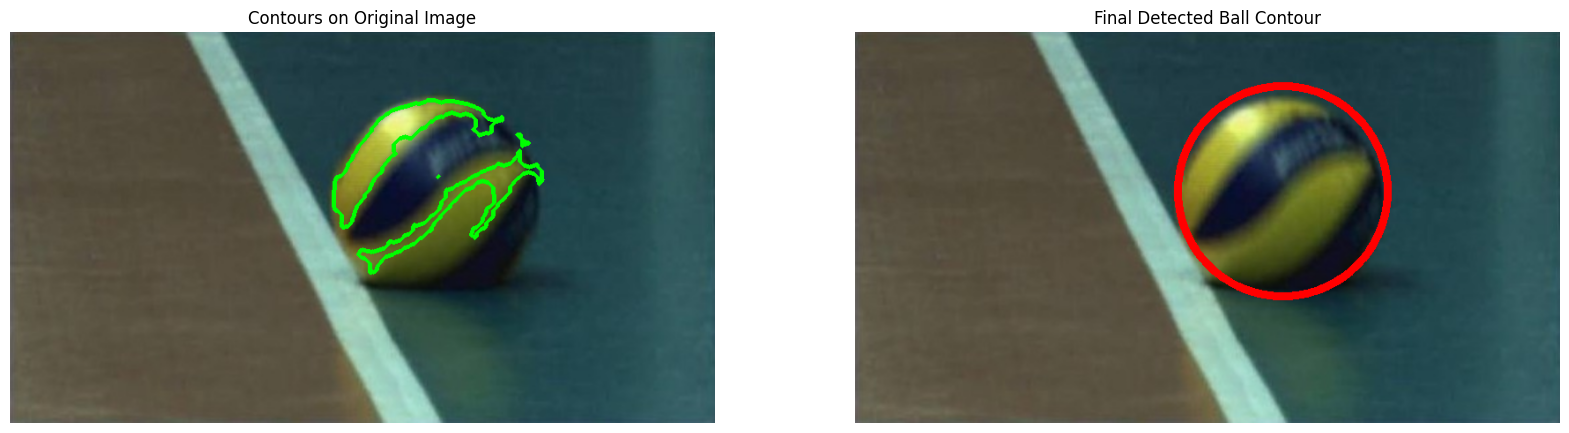

In [111]:
def detect_ball(image_rgb, ball_mask):
    
    # Find contours that are circular in shape
    contours, _ = cv2.findContours(ball_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    image_rgb_contours = image_rgb.copy()
    image_rgb_contours = cv2.drawContours(image_rgb_contours, contours=contours, contourIdx=-1, color=(0,255,0), thickness=3)

    # Combine the two largest contours
    contours = sorted(contours, key=cv2.contourArea)
    largest_contour = max(contours, key=cv2.contourArea)
    second_largest_contour = contours[-2]
    combined_contour = np.concatenate((largest_contour, second_largest_contour))

    # Draw a circle around the combined contour
    (x, y), radius = cv2.minEnclosingCircle(combined_contour)
    center = (int(x), int(y))
    radius = int(radius)
    image_rgb = cv2.circle(image_rgb, center, radius, color=(255,0,0), thickness=7)

    # Displays the results
    plt.figure(figsize=(20,10))
    plt.subplot(1,2,1)
    plt.title('Contours on Original Image')
    plt.imshow(image_rgb_contours)
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.title('Final Detected Ball Contour')
    plt.imshow(image_rgb)
    plt.axis('off')

    return image_rgb

detected_image = detect_ball(image_rgb, ball_mask)


### Decision Making

This function will combine the line detection result image and ball detection result image

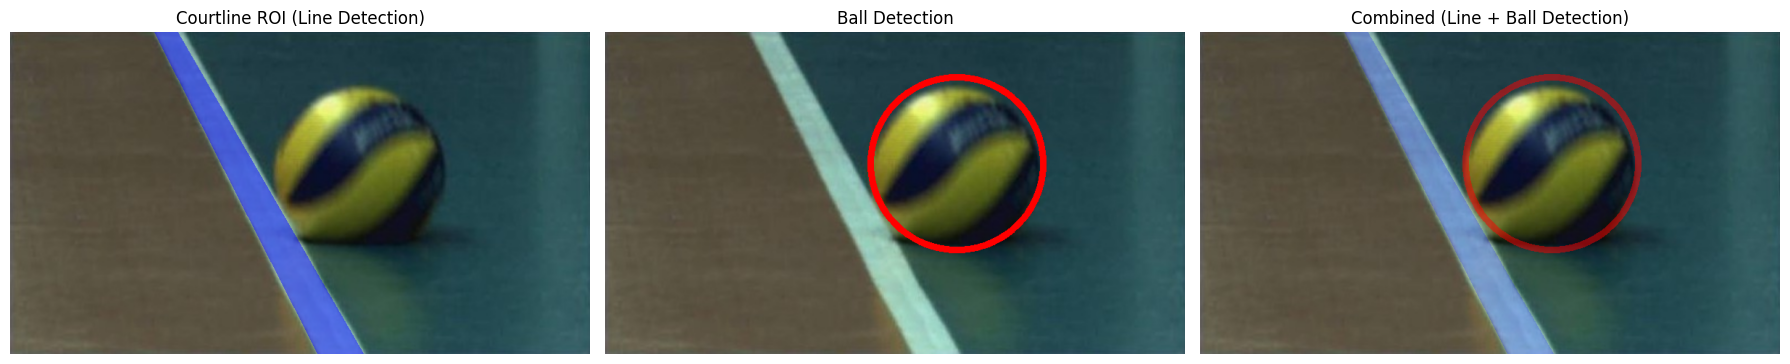

In [112]:
def combine_detections(line_detection, ball_detection):
    # Copy the original images for both detections
    line_img = line_detection.copy()
    ball_img = ball_detection.copy()

    # Ensure both images are in the same color format (both BGR in this case)
    line_img_bgr = cv2.cvtColor(line_img, cv2.COLOR_RGB2BGR)
    ball_img_bgr = cv2.cvtColor(ball_img, cv2.COLOR_RGB2BGR)

    # Combine the two images (overlay them) with adjusted weights for better visibility
    combined_img = cv2.addWeighted(line_img_bgr, 0.5, ball_img_bgr, 0.5, 0)  # Adjusting weight for better visibility
    combined_img_rgb = cv2.cvtColor(combined_img, cv2.COLOR_BGR2RGB)

    # Display the images
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Line Detection Image
    axes[0].imshow(line_img)
    axes[0].set_title('Courtline ROI (Line Detection)')
    axes[0].axis('off')

    # Ball Detection Image
    axes[1].imshow(ball_img)
    axes[1].set_title('Ball Detection')
    axes[1].axis('off')

    # Combined Image
    axes[2].imshow(combined_img_rgb)
    axes[2].set_title('Combined (Line + Ball Detection)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Example usage:
combine_detections(vis_roi, detected_image)


This function determines if the ball is "IN" or "OUT" by checking whether the detected ball mask overlaps with the court line mask. If any part of the ball touches the court line, it outputs "IN"; otherwise, it outputs "OUT". The result is displayed visually as a combined overlay with the decision in the plot title.

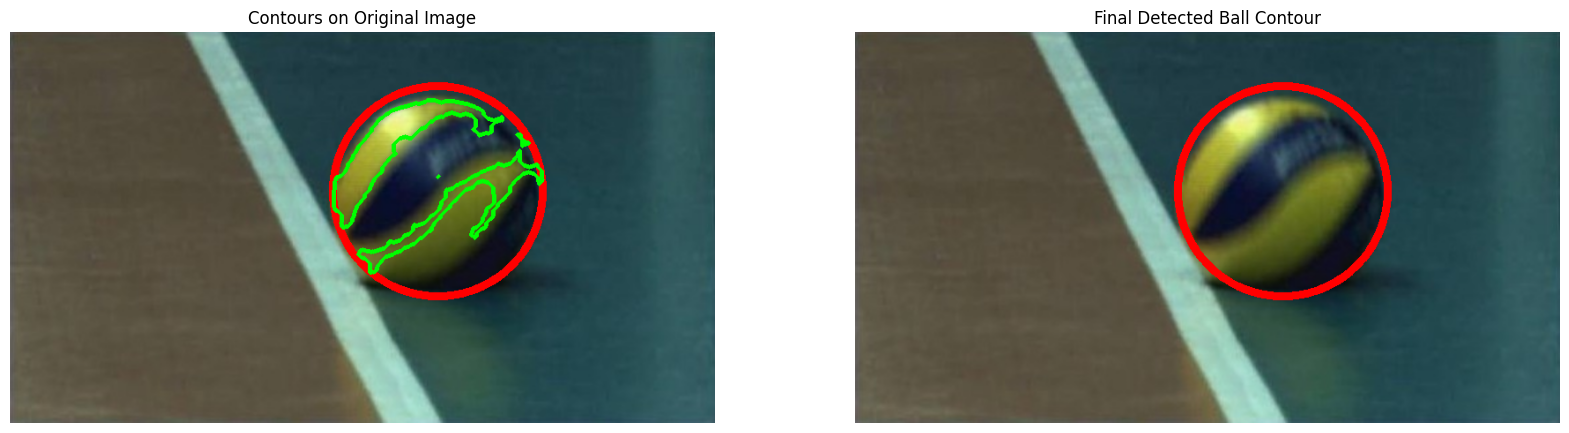

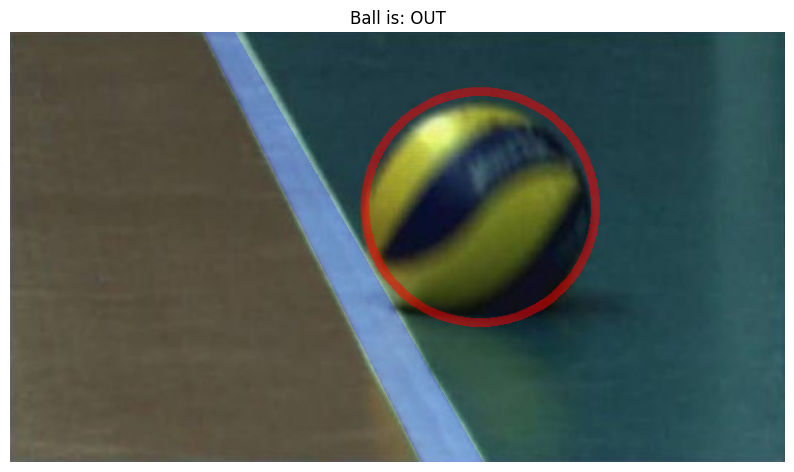

Overlap area (pixels): 0


In [ ]:
# Decision if the ball is "IN" or "OUT"
def decide_in_or_out(line_roi_mask, ball_mask, image_rgb, lines):
    """
    Decides IN/OUT by checking if the ball mask overlaps with the court line mask.
    Any overlap means "IN", otherwise "OUT".
    """
    # Calculate overlap area
    overlapping = cv2.bitwise_and(ball_mask, line_roi_mask)
    overlap_area = np.count_nonzero(overlapping)
    decision = "IN" if overlap_area > 0 else "OUT"

    # For visualization (combine overlays)
    # vis_roi = compute_courtline_ROI(image_rgb, lines)[1]
    # ball_overlay = detect_ball(image_rgb, ball_mask)
    
    # Overlay
    line_img_bgr = cv2.cvtColor(vis_roi, cv2.COLOR_RGB2BGR)
    ball_img_bgr = cv2.cvtColor(ball_overlay, cv2.COLOR_RGB2BGR)
    combined_img = cv2.addWeighted(line_img_bgr, 0.5, ball_img_bgr, 0.5, 0)
    combined_img_rgb = cv2.cvtColor(combined_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(combined_img_rgb)
    plt.title(f"Ball is: {decision}")
    plt.axis("off")
    plt.show()
    print(f"Overlap area (pixels): {overlap_area}")
    return decision, overlap_area

# Example usage:
decision, area = decide_in_or_out(line_roi_mask, ball_mask, image_rgb, lines)
